# Sesión 10: Calendar + Lag Features sobre LSTM+TDA v1

## Objetivo
Mejorar el LSTM+TDA v1 (Sesión 6) agregando:
- **Variant A**: features de mes (sin/cos) — codifica estacionalidad anual explícita
- **Variant B**: Variant A + lag-1 + lag-12 de precio — codifica contexto de nivel

Comparar 3 modelos sobre el mismo split 70/15/15 para aislar el efecto de cada feature group.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

W, D, TAU, L = 36, 6, 3, 12
N_BASE = 152   # TDA v1 features per timestep

print(f"TF {tf.__version__}")

TF 2.21.0


## §1 — Carga de Datos y Features TDA v1

In [2]:
df     = pd.read_csv('../data/input/WPUSI01102B.csv', parse_dates=['observation_date'])
prices = df['WPUSI01102B'].values.astype(float)
dates  = df['observation_date'].values
print(f"Prices: {len(prices)} pts  [{prices.min():.1f}, {prices.max():.1f}]")

# Load TDA v1 cache (saved by Sesion-6)
F = np.load('../data/output/F_tda_features.npy')   # shape (180, 152)
assert F.shape == (len(prices) - W + 1, N_BASE), f"Unexpected shape: {F.shape}"
print(f"F_tda v1: {F.shape}  (price[t] is F[:,0])")
# F[t,0] = prices[W-1+t] = last price in window t
# Sequence i: X[i] = F[i:i+12], target = prices[47+i]
n_seq = len(F) - L   # = 168
print(f"Sequences: {n_seq}")
assert n_seq == 168

Prices: 215 pts  [69.2, 299.4]
F_tda v1: (180, 152)  (price[t] is F[:,0])
Sequences: 168


## §2 — Feature Engineering: Calendar + Lag

**Variant A** appends `month_sin`, `month_cos` of the TARGET month → 154 features.  
**Variant B** also appends `lag_1` (price 1 month before target) and `lag_12` (same month last year) → 156 features.  
All extra features broadcast constant across the L=12 timesteps of each sequence.

In [3]:
X_base_list, X_A_list, X_B_list, y_list = [], [], [], []

for i in range(n_seq):
    target_idx = 47 + i   # = W + i + L - 1

    # ── Calendar features (target month) ─────────────────
    month = pd.Timestamp(dates[target_idx]).month
    m_sin = np.sin(2 * np.pi * month / 12)
    m_cos = np.cos(2 * np.pi * month / 12)

    # ── Lag features (raw price, same scale as y) ─────────
    lag_1  = prices[target_idx - 1]    # = prices[46+i]
    lag_12 = prices[target_idx - 12]   # = prices[35+i]

    # ── Base sequence ─────────────────────────────────────
    base_seq = F[i : i + L]            # (12, 152)

    # ── Extra features broadcast to all L timesteps ───────
    cal_broadcast  = np.tile([m_sin, m_cos],                    (L, 1))  # (12, 2)
    lag_broadcast  = np.tile([m_sin, m_cos, lag_1, lag_12],     (L, 1))  # (12, 4)

    X_base_list.append(base_seq)
    X_A_list.append(np.concatenate([base_seq, cal_broadcast], axis=1))
    X_B_list.append(np.concatenate([base_seq, lag_broadcast], axis=1))
    y_list.append(prices[target_idx])

X_base = np.array(X_base_list)   # (168, 12, 152)
X_A    = np.array(X_A_list)      # (168, 12, 154)
X_B    = np.array(X_B_list)      # (168, 12, 156)
y      = np.array(y_list)        # (168,)

assert X_base.shape == (168, 12, 152)
assert X_A.shape    == (168, 12, 154)
assert X_B.shape    == (168, 12, 156)
print(f"X_base {X_base.shape}  X_A {X_A.shape}  X_B {X_B.shape}")
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")

X_base (168, 12, 152)  X_A (168, 12, 154)  X_B (168, 12, 156)
y range: [69.2, 299.4]


## §3 — Split + Normalización

Split cronológico 70/15/15. Scalers fit solo en train.

In [4]:
n_train = int(n_seq * 0.70)   # 117
n_val   = int(n_seq * 0.15)   # 25
n_test  = n_seq - n_train - n_val  # 26

def split_scale(X, n_train, n_val, n_feat):
    X_tr, X_v, X_te = X[:n_train], X[n_train:n_train+n_val], X[n_train+n_val:]
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr.reshape(-1, n_feat)).reshape(X_tr.shape)
    X_v_s  = sc.transform(X_v.reshape(-1, n_feat)).reshape(X_v.shape)
    X_te_s = sc.transform(X_te.reshape(-1, n_feat)).reshape(X_te.shape)
    return X_tr_s, X_v_s, X_te_s

X_base_tr, X_base_v, X_base_te = split_scale(X_base, n_train, n_val, 152)
X_A_tr,    X_A_v,    X_A_te    = split_scale(X_A,    n_train, n_val, 154)
X_B_tr,    X_B_v,    X_B_te    = split_scale(X_B,    n_train, n_val, 156)

y_train = y[:n_train]
y_val   = y[n_train:n_train+n_val]
y_test  = y[n_train+n_val:]

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).flatten()

# Test dates for plot
test_start_t = 47 + n_train + n_val
test_dates   = dates[test_start_t : test_start_t + n_test]

print(f"Train={n_train}  Val={n_val}  Test={n_test}")
print("Normalización ✓")

Train=117  Val=25  Test=26
Normalización ✓


## §4 — Baseline: LSTM+TDA v1 Reentrenado (152 features)

Mismo modelo que Sesión 6 — reentrenado en el mismo split para comparación honesta.

In [5]:
def build_lstm(n_features, keras_name='LSTM_TDA'):
    model = Sequential([
        LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1,
             input_shape=(L, n_features)),
        LSTM(32, dropout=0.2, recurrent_dropout=0.1),
        Dense(16, activation='relu'),
        Dense(1)
    ], name=keras_name)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mae')
    return model

def train_eval(X_tr, X_v, X_te, label, n_features):
    tf.random.set_seed(42); np.random.seed(42)
    # Keras model name must match ^[A-Za-z0-9.][A-Za-z0-9_.\/>-]*$
    keras_name = 'LSTM_' + str(n_features) + 'f'
    model = build_lstm(n_features, keras_name)
    cb = EarlyStopping(monitor='val_loss', patience=20,
                       restore_best_weights=True, verbose=0)
    model.fit(X_tr, y_train_s, validation_data=(X_v, y_val_s),
              epochs=200, batch_size=16, callbacks=[cb], verbose=0)
    preds_s = model.predict(X_te, verbose=0).flatten()
    preds   = scaler_y.inverse_transform(preds_s.reshape(-1,1)).flatten()
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"{label:35s}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
    return preds, mae, rmse, r2

preds_base, mae_base, rmse_base, r2_base = train_eval(
    X_base_tr, X_base_v, X_base_te, 'Baseline (152)', 152)

Baseline (152)                       MAE=31.9333  RMSE=40.3877  R²=0.4998


## §5 — Model A: LSTM+TDA v1 + Calendar (154 features)

Agrega `month_sin` y `month_cos` del mes objetivo. El modelo ahora "sabe" en qué mes del año se hace la predicción.

In [6]:
preds_A, mae_A, rmse_A, r2_A = train_eval(
    X_A_tr, X_A_v, X_A_te, 'Model A +Calendar (154)', 154)

Model A +Calendar (154)              MAE=30.3069  RMSE=39.1598  R²=0.5297


## §6 — Model B: LSTM+TDA v1 + Calendar + Lag (156 features)

Agrega además `lag_1` (precio un mes antes del objetivo) y `lag_12` (mismo mes año anterior).  
Nota: `lag_1` equivale a `F[i+11,0]` que ya está en las 152 features base, pero explícito  
en canal separado + `lag_12` añade información de estacionalidad interanual.

In [7]:
preds_B, mae_B, rmse_B, r2_B = train_eval(
    X_B_tr, X_B_v, X_B_te, 'Model B +Cal+Lag (156)', 156)

Model B +Cal+Lag (156)               MAE=30.0979  RMSE=38.0850  R²=0.5552


## §7 — Comparación + Forecast Plot


  COMPARACIÓN FINAL — Test Set
                 Modelo  Features     MAE    RMSE     R²   Δ MAE
         Baseline (152)       152 31.9333 40.3877 0.4998  0.0000
Model A +Calendar (154)       154 30.3069 39.1598 0.5297 -1.6264
 Model B +Cal+Lag (156)       156 30.0979 38.0850 0.5552 -1.8353


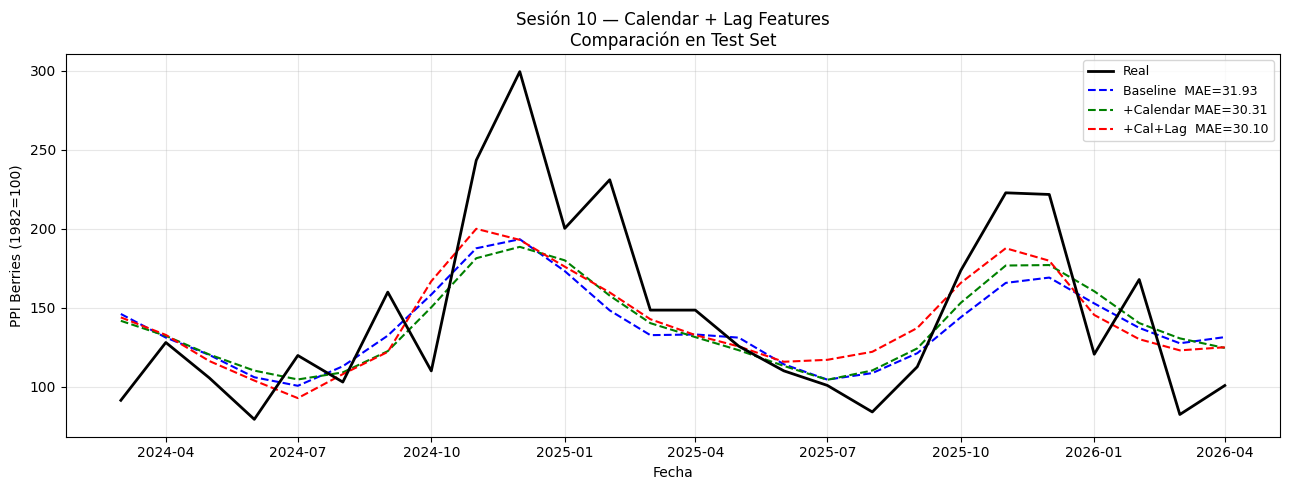

In [8]:
# ── Comparison table ──────────────────────────────────────
df_res = pd.DataFrame({
    'Modelo':   ['Baseline (152)', 'Model A +Calendar (154)', 'Model B +Cal+Lag (156)'],
    'Features': [152, 154, 156],
    'MAE':      [mae_base, mae_A, mae_B],
    'RMSE':     [rmse_base, rmse_A, rmse_B],
    'R\u00b2':       [r2_base, r2_A, r2_B],
    '\u0394 MAE':    [0.0, mae_A - mae_base, mae_B - mae_base]
})
print("\n" + "="*65)
print("  COMPARACIÓN FINAL — Test Set")
print("="*65)
print(df_res.to_string(index=False, float_format='{:.4f}'.format))
print("="*65)

# ── Forecast plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_test,    'k-',  linewidth=2,   label='Real', zorder=5)
ax.plot(test_dates, preds_base,'b--', linewidth=1.5, label=f'Baseline  MAE={mae_base:.2f}')
ax.plot(test_dates, preds_A,   'g--', linewidth=1.5, label=f'+Calendar MAE={mae_A:.2f}')
ax.plot(test_dates, preds_B,   'r--', linewidth=1.5, label=f'+Cal+Lag  MAE={mae_B:.2f}')
ax.set_xlabel('Fecha')
ax.set_ylabel('PPI Berries (1982=100)')
ax.set_title('Sesión 10 — Calendar + Lag Features\nComparación en Test Set')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## §8 — Preguntas de Análisis

1. **¿Calendar features mejoraron MAE?** Compara Baseline vs Model A (Δ MAE). ¿El LSTM aprovecha la señal estacional del mes objetivo, o ya la infería del embedding TDA?

2. **¿Lag-1 + lag-12 añadieron valor sobre el calendario?** Compara Model A vs Model B. Nota: lag-1 ya está implícito en F[:,0] del último timestep. ¿La redundancia explícita ayudó o fue ruido?

3. **¿Visualmente las predicciones siguen "shifteadas"?** Observa el forecast plot. ¿Model B, que tiene lag-1 explícito, muestra un shift más pronunciado o menos que el Baseline?

4. **¿Cuál feature group aporta más?** TDA topológico (152), calendario (2) o lags (2). ¿Qué esperarías con N=168 muestras?

5. **Comparación histórica:** Sesión 8 LSTM+TDA v2 alcanzó MAE=27.92. ¿Los features calendario/lag en v1 alcanzan ese nivel? ¿Qué explica la diferencia?